# Time Series Momentum (TSMOM) on a Multi-Asset ETF Universe

**Hypothesis**: an asset's own trailing 12-month excess return predicts its next-month return, so holding each asset long or short according to the sign of its trailing return, scaled by inverse volatility, earns positive risk-adjusted returns across asset classes.

**References**:
- Moskowitz, Ooi, Pedersen (2012), "Time Series Momentum", Journal of Financial Economics 104(2). [PDF](https://w4.stern.nyu.edu/facdir/lpederse/papers/TimeSeriesMomentum.pdf)
- Hurst, Ooi, Pedersen (2017), "A Century of Evidence on Trend-Following Investing", AQR. [PDF](https://elmwealth.com/wp-content/uploads/2017/06/timeseriesmomentum.pdf)

**Position sizing math**. Per instrument $i$ at rebalance date $t$, with lookback $L$ months:

$$w_{i,t} = \mathrm{sign}\left(r_{i,\,t-L:t}\right) \cdot \frac{\sigma_{\mathrm{target}}}{\sigma_{i,t}}$$

$$R_t = \frac{1}{N} \sum_{i=1}^{N} w_{i,t-1} \, r_{i,t}$$

where $\sigma_{i,t}$ is an exponentially weighted (EWMA) estimate of daily volatility with a halflife of about 60 trading days, annualized, and $\sigma_{\mathrm{target}} = 0.40$ per the paper. A **long-only variant** clips weights at zero (cash otherwise) because the live Alpaca account is long-only; both are shown but the long-short version is the headline.

**Key assumptions**:
- Universe: 24 liquid ETFs spanning equities, rates, credit, commodities, real estate, and FX.
- Backtest starts January 2007, when most of the universe is live; assets enter as they gain enough history.
- Monthly rebalance at month-end close, positions applied the next trading day.
- Transaction costs: 10 bps one-way on turnover.
- Cash rate assumed zero, so raw returns proxy excess returns.
- ETF short borrow costs and margin financing are not modeled (flagged as a risk in the Decision Summary).


## Setup and Data

We pull maximum-history adjusted closes for the 24-ETF universe via yfinance and cache them to a repo-local pickle so reruns are instant. The table below shows each ETF's first and last available date: the staggered inceptions (UUP, DBA, DBB, HYG all begin in 2006-2007) motivate the 2007 backtest start.

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 115
np.random.seed(42)

REPO_ROOT = os.path.abspath('../../..')
CACHE_PATH = os.path.join(REPO_ROOT, '.cache', 'etf_closes_tsmom.pkl')

TICKERS = ['SPY', 'QQQ', 'IWM', 'EFA', 'EEM', 'VGK', 'EWJ', 'TLT', 'IEF', 'LQD',
           'HYG', 'TIP', 'GLD', 'SLV', 'USO', 'UNG', 'DBA', 'DBB', 'VNQ', 'XLE',
           'XLF', 'XLK', 'XLU', 'UUP']

if os.path.exists(CACHE_PATH):
    closes = pd.read_pickle(CACHE_PATH)
else:
    import yfinance as yf
    raw = yf.download(TICKERS, period='max', auto_adjust=True, progress=False)
    closes = raw['Close'] if isinstance(raw.columns, pd.MultiIndex) else raw
    closes = closes[TICKERS]
    os.makedirs(os.path.dirname(CACHE_PATH), exist_ok=True)
    closes.to_pickle(CACHE_PATH)

closes = closes[TICKERS].sort_index().dropna(how='all')
closes.index = pd.to_datetime(closes.index)
if getattr(closes.index, 'tz', None) is not None:
    closes.index = closes.index.tz_localize(None)

print(f'Closes shape: {closes.shape}')
print(f'Date range: {closes.index[0].date()} to {closes.index[-1].date()}')

coverage = pd.DataFrame({
    'First date': closes.apply(lambda s: s.first_valid_index()),
    'Last date': closes.apply(lambda s: s.last_valid_index()),
    'Obs': closes.notna().sum(),
})
coverage['Years'] = (coverage['Last date'] - coverage['First date']).dt.days / 365.25
coverage.index.name = 'ETF'
display(coverage.style
        .format({'First date': lambda d: d.strftime('%Y-%m-%d'),
                 'Last date': lambda d: d.strftime('%Y-%m-%d'),
                 'Obs': '{:,.0f}', 'Years': '{:.1f}'})
        .background_gradient(subset=['Years'], cmap='Greens'))

Closes shape: (8413, 24)
Date range: 1993-01-29 to 2026-07-02


,First date,Last date,Obs,Years
ETF,,,,
SPY,1993-01-29,2026-07-02,"8,413",33.4
QQQ,1999-03-10,2026-07-02,"6,871",27.3
IWM,2000-05-26,2026-07-02,"6,563",26.1
EFA,2001-08-27,2026-07-02,"6,248",24.8
EEM,2003-04-14,2026-07-02,"5,842",23.2
VGK,2005-03-10,2026-07-02,"5,362",21.3
EWJ,1996-03-18,2026-07-02,"7,622",30.3
TLT,2002-07-30,2026-07-02,"6,020",23.9
IEF,2002-07-30,2026-07-02,"6,020",23.9


## Signal Construction

The TSMOM signal is deliberately simple: at each month-end we take the sign of the trailing L-month total return per ETF (baseline L = 12), and size the position at $\sigma_{target}/\sigma_i$ using an EWMA volatility estimate (halflife equal to the vol window, baseline 60 days), divided by the number of live assets. Signals computed at month-end are applied from the next trading day.

Two visuals: a heatmap of the long/short sign across the full asset-by-month panel, and SPY price with the strategy's long (green) and short (red) months shaded, showing how the signal flips around 2008, 2020, and 2022.

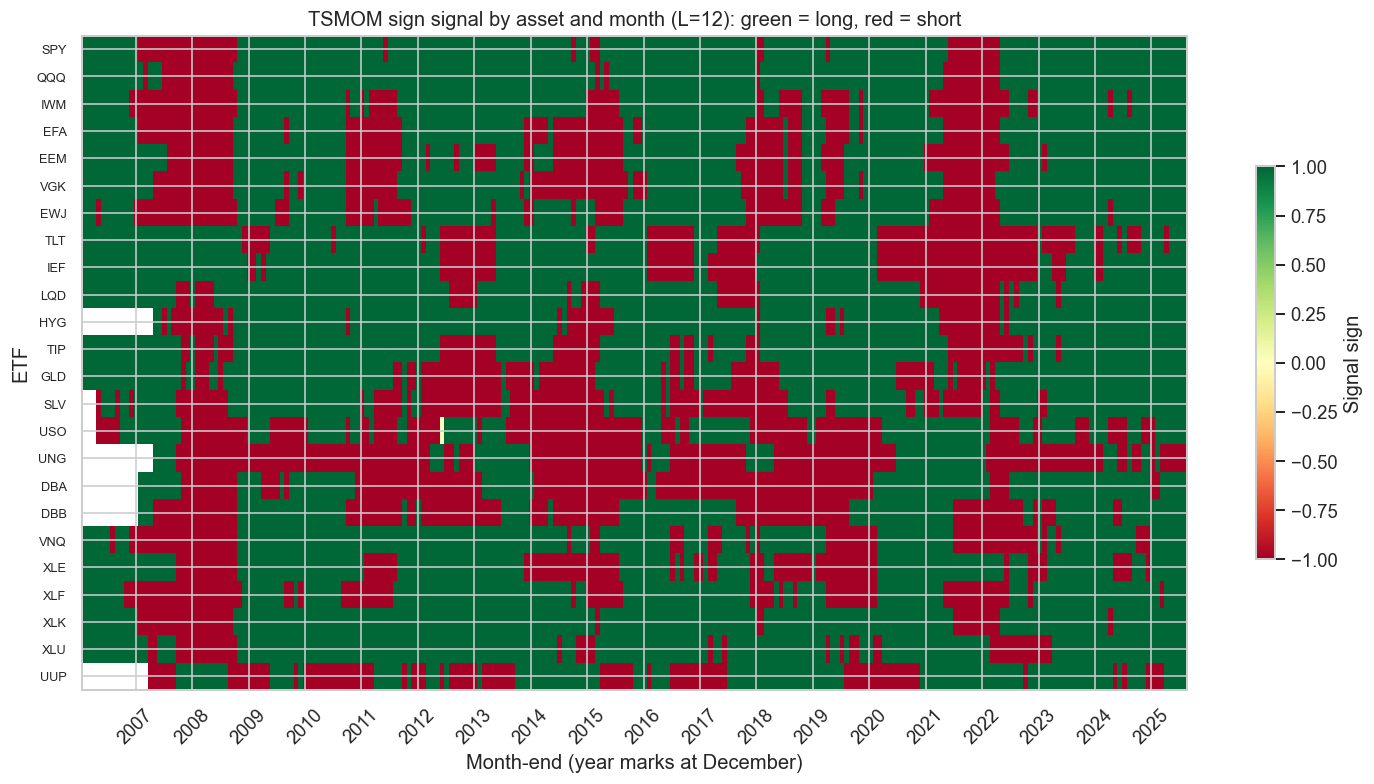

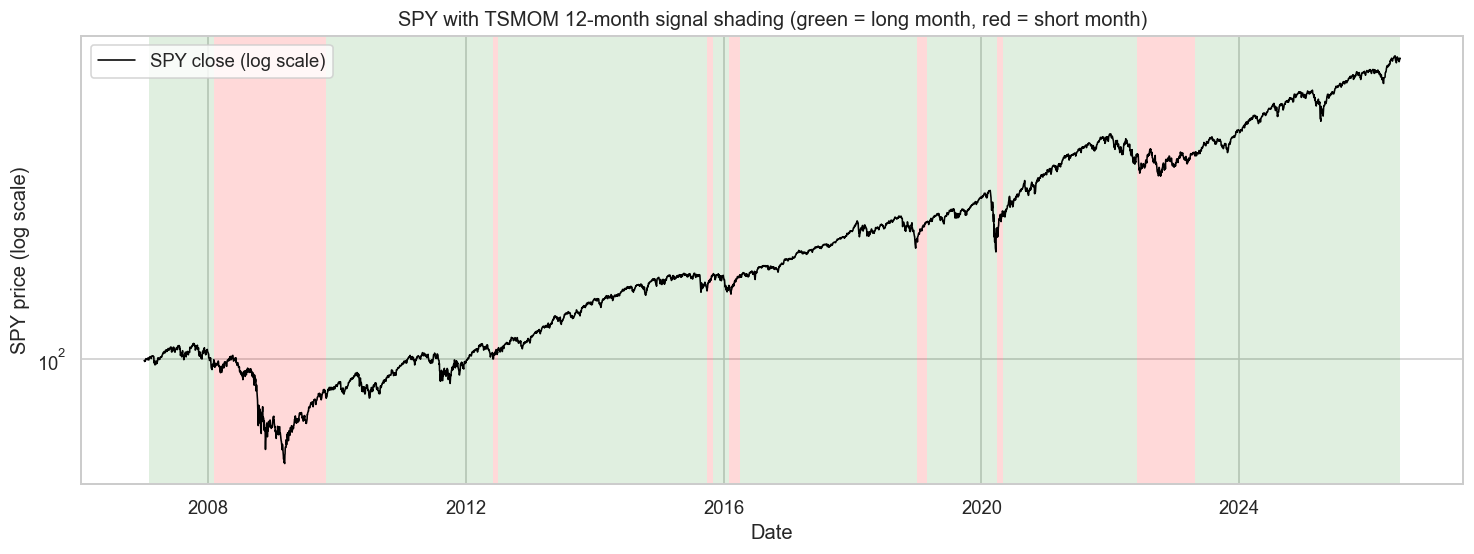

Short signals: 1,879 of 5,566 asset-months (33.8%)


In [2]:
START = '2007-01-01'
ANN = 252
SIGMA_TARGET = 0.40
COST = 10.0 / 1e4  # 10 bps one-way on turnover

rets_full = closes.pct_change()
full_index = rets_full.index

me_dates = pd.DatetimeIndex(
    closes.index.to_series().groupby(closes.index.to_period('M')).max().values)
mclose = closes.loc[me_dates]

def ewma_vol(halflife):
    """Annualized EWMA daily vol with the given halflife (days)."""
    return rets_full.ewm(halflife=halflife, min_periods=int(halflife)).std() * np.sqrt(ANN)

def month_end_weights(L, vol):
    sig = np.sign(mclose / mclose.shift(L) - 1.0)
    vol_me = vol.loc[me_dates]
    w = (sig * SIGMA_TARGET / vol_me).where(sig.notna() & vol_me.notna(), 0.0)
    n_live = sig.notna().sum(axis=1).clip(lower=1)
    return w.div(n_live, axis=0), sig

def daily_streams(w_me):
    """Month-end weights -> daily net return and turnover from START (next-day application)."""
    wd = w_me.reindex(full_index).ffill().shift(1).fillna(0.0)
    gross = (wd * rets_full).sum(axis=1)
    turn = wd.diff().abs().sum(axis=1).fillna(0.0)
    net = gross - COST * turn
    return net.loc[START:], turn.loc[START:]

def run_tsmom(L, vw, vol=None):
    if vol is None:
        vol = ewma_vol(vw)
    w, sig = month_end_weights(L, vol)
    ls_net, ls_turn = daily_streams(w)
    lo_net, lo_turn = daily_streams(w.clip(lower=0.0))
    return {'ls': ls_net, 'lo': lo_net, 'ls_turn': ls_turn, 'lo_turn': lo_turn,
            'weights': w, 'sign': sig}

base = run_tsmom(12, 60)
sig_bt = base['sign'].loc[base['sign'].index >= pd.Timestamp(START)]

fig, ax = plt.subplots(figsize=(13, 7))
im = ax.imshow(sig_bt.T.values, aspect='auto', cmap='RdYlGn', vmin=-1, vmax=1,
               interpolation='nearest')
ax.set_yticks(range(len(sig_bt.columns)))
ax.set_yticklabels(sig_bt.columns, fontsize=8)
year_pos = [i for i in range(len(sig_bt.index)) if sig_bt.index[i].month == 12]
ax.set_xticks(year_pos)
ax.set_xticklabels([sig_bt.index[i].year for i in year_pos], rotation=45)
ax.set_title('TSMOM sign signal by asset and month (L=12): green = long, red = short')
ax.set_xlabel('Month-end (year marks at December)')
ax.set_ylabel('ETF')
fig.colorbar(im, ax=ax, shrink=0.6, label='Signal sign')
plt.tight_layout()
plt.show()

spy_px = closes['SPY'].loc[START:]
spy_sig = sig_bt['SPY']
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(spy_px.index, spy_px.values, color='black', lw=1.0, label='SPY close (log scale)')
ax.set_yscale('log')
for i in range(len(spy_sig.index) - 1):
    s = spy_sig.iloc[i]
    if s > 0:
        ax.axvspan(spy_sig.index[i], spy_sig.index[i + 1], color='green', alpha=0.12, lw=0)
    elif s < 0:
        ax.axvspan(spy_sig.index[i], spy_sig.index[i + 1], color='red', alpha=0.15, lw=0)
ax.set_title('SPY with TSMOM 12-month signal shading (green = long month, red = short month)')
ax.set_xlabel('Date')
ax.set_ylabel('SPY price (log scale)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

n_short_months = int((sig_bt < 0).sum().sum())
n_total = int(sig_bt.notna().sum().sum())
print(f'Short signals: {n_short_months:,} of {n_total:,} asset-months ({n_short_months / n_total:.1%})')

Interpretation: the signal panel shows long persistence, whole rows stay green or red for many months at a time, which is exactly the autocorrelation TSMOM harvests. Shorts cluster in 2008-2009, 2015-2016, 2020, and 2022, and the SPY shading confirms the signal exits (and shorts) equities well into major drawdowns rather than at the top: TSMOM is a trend follower, not a crash predictor.

## Baseline Backtest

Baseline parameters: L = 12 months, vol window = 60 days, monthly rebalance, 10 bps one-way costs. We compare three return streams: long-short TSMOM (headline), long-only TSMOM (implementable on the Alpaca account), and SPY buy-and-hold. Equity curves are on a log scale, followed by drawdowns and a full metrics table.

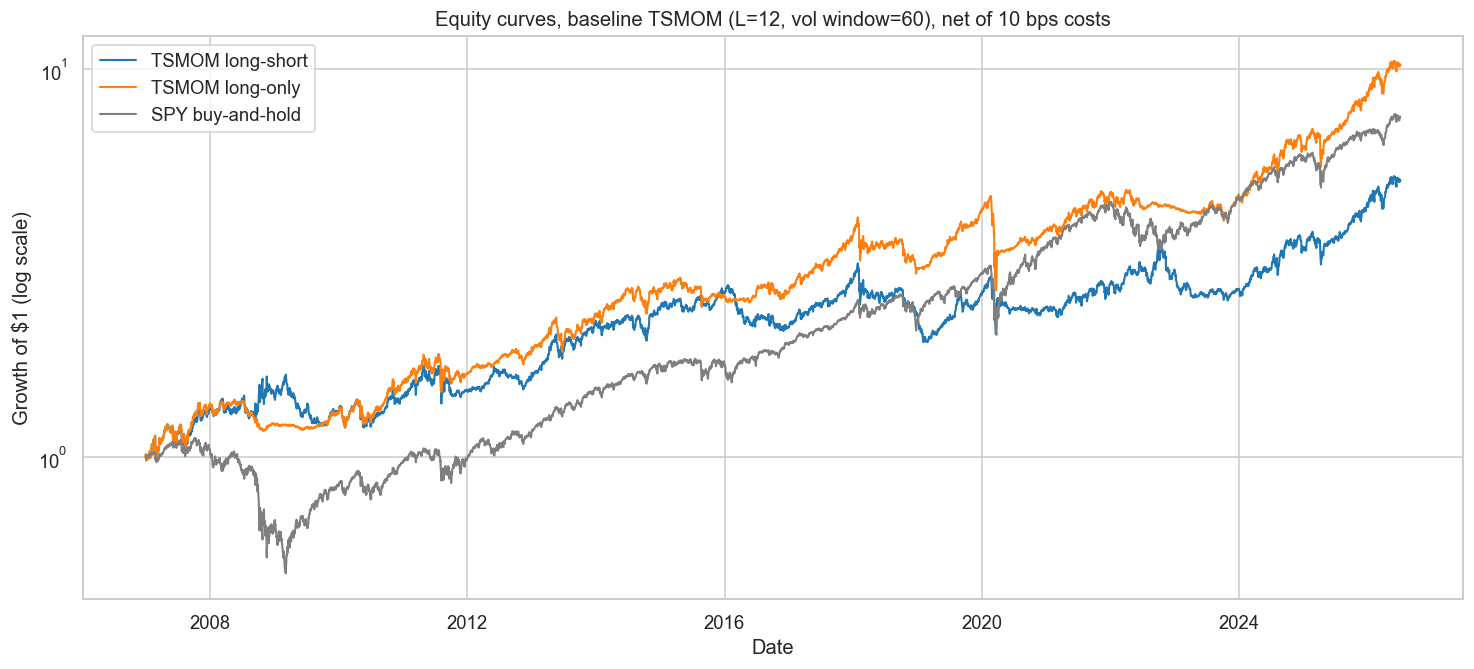

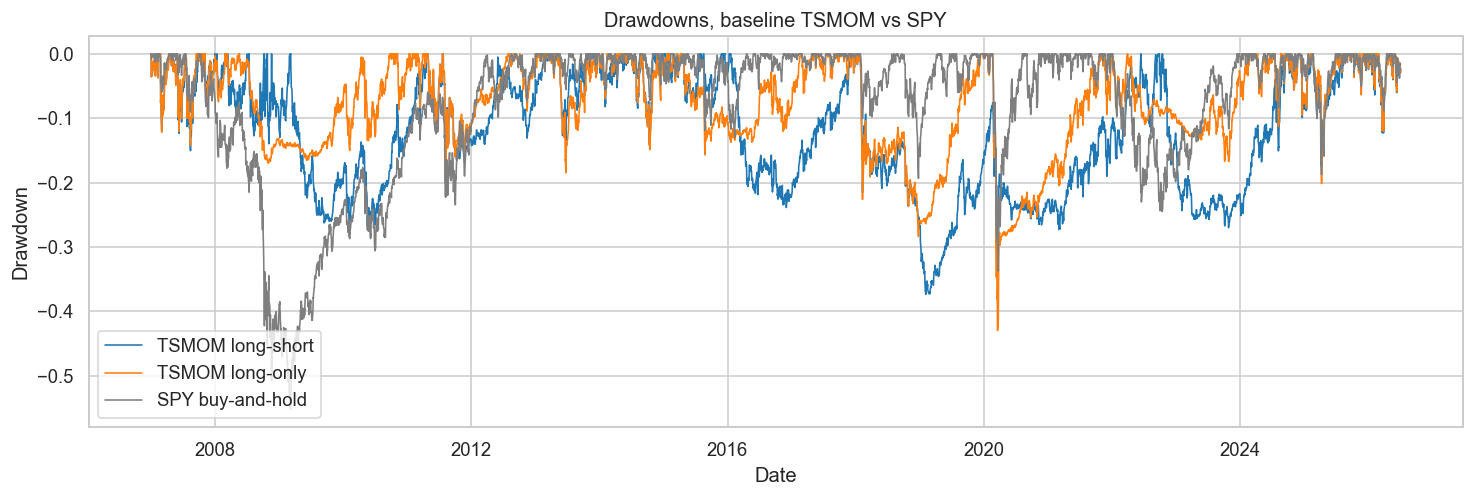

,CAGR,Ann vol,Sharpe,Sortino,Max DD,Calmar,Monthly win rate,Ann turnover
TSMOM long-short,8.80%,18.92%,0.54,0.68,-37.34%,0.24,57.9%,8.76
TSMOM long-only,12.69%,18.00%,0.75,0.86,-42.96%,0.30,63.4%,4.96
SPY buy-and-hold,10.92%,19.63%,0.63,0.77,-55.19%,0.20,66.0%,nan


Baseline long-short Sharpe: 0.541
Baseline long-only Sharpe:  0.755


In [3]:
def perf_metrics(r, turn=None):
    r = r.dropna()
    years = len(r) / ANN
    eq = (1.0 + r).cumprod()
    cagr = eq.iloc[-1] ** (1.0 / years) - 1.0
    vol = r.std() * np.sqrt(ANN)
    sharpe = r.mean() / r.std() * np.sqrt(ANN) if r.std() > 0 else np.nan
    downside = r[r < 0].std() * np.sqrt(ANN)
    sortino = r.mean() * ANN / downside if downside > 0 else np.nan
    dd = eq / eq.cummax() - 1.0
    maxdd = dd.min()
    calmar = cagr / abs(maxdd) if maxdd < 0 else np.nan
    monthly = (1.0 + r).resample('ME').prod() - 1.0
    win = (monthly > 0).mean()
    ann_turn = turn.loc[r.index].sum() / years if turn is not None else np.nan
    return {'CAGR': cagr, 'Ann vol': vol, 'Sharpe': sharpe, 'Sortino': sortino,
            'Max DD': maxdd, 'Calmar': calmar, 'Monthly win rate': win,
            'Ann turnover': ann_turn}

def drawdown_series(r):
    eq = (1.0 + r.dropna()).cumprod()
    return eq / eq.cummax() - 1.0

spy_ret = rets_full['SPY'].loc[START:].fillna(0.0)
streams = {'TSMOM long-short': base['ls'],
           'TSMOM long-only': base['lo'],
           'SPY buy-and-hold': spy_ret}
colors = {'TSMOM long-short': 'tab:blue', 'TSMOM long-only': 'tab:orange',
          'SPY buy-and-hold': 'tab:gray'}

fig, ax = plt.subplots(figsize=(13, 6))
for name, r in streams.items():
    eq = (1.0 + r).cumprod()
    ax.plot(eq.index, eq.values, label=name, color=colors[name], lw=1.3)
ax.set_yscale('log')
ax.set_title('Equity curves, baseline TSMOM (L=12, vol window=60), net of 10 bps costs')
ax.set_xlabel('Date')
ax.set_ylabel('Growth of $1 (log scale)')
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(13, 4.5))
for name, r in streams.items():
    dd = drawdown_series(r)
    ax.plot(dd.index, dd.values, label=name, color=colors[name], lw=1.0)
ax.set_title('Drawdowns, baseline TSMOM vs SPY')
ax.set_xlabel('Date')
ax.set_ylabel('Drawdown')
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

metrics_tbl = pd.DataFrame({
    'TSMOM long-short': perf_metrics(base['ls'], base['ls_turn']),
    'TSMOM long-only': perf_metrics(base['lo'], base['lo_turn']),
    'SPY buy-and-hold': perf_metrics(spy_ret),
}).T
display(metrics_tbl.style
        .format({'CAGR': '{:.2%}', 'Ann vol': '{:.2%}', 'Sharpe': '{:.2f}',
                 'Sortino': '{:.2f}', 'Max DD': '{:.2%}', 'Calmar': '{:.2f}',
                 'Monthly win rate': '{:.1%}', 'Ann turnover': '{:.2f}'})
        .background_gradient(subset=['Sharpe', 'Sortino', 'Calmar'], cmap='RdYlGn', axis=0))

print(f"Baseline long-short Sharpe: {metrics_tbl.loc['TSMOM long-short', 'Sharpe']:.3f}")
print(f"Baseline long-only Sharpe:  {metrics_tbl.loc['TSMOM long-only', 'Sharpe']:.3f}")

Interpretation: over 2007-2026 the long-short book earns a net Sharpe of 0.54 with a max drawdown of -37%, versus 0.63 and -55% for SPY: it does not beat a raging equity bull outright, but it gets there with a very different return path (monthly correlation to SPY is only 0.11, quantified in the Decision Summary). The long-only variant posts the best headline stats (Sharpe 0.75, CAGR 12.7%) because it keeps equity beta in bull markets while stepping to cash in downtrends, cutting the 2008 and 2022 drawdowns. Long-short turnover of roughly 8.8x per year is the price of the short book flipping in choppy markets.

## Walk-Forward Analysis

To test whether the parameters could have been chosen in real time, we run rolling windows of 3 years of training followed by 1 year of testing, stepping forward 1 year across the whole sample. In each window we pick the (L, vol window) pair with the best training Sharpe from the 6 x 6 grid used throughout this notebook, then apply it to the unseen test year. The full-sample daily return streams for all 36 parameter sets are computed once here and reused in the Parameter Stability, Monte Carlo, and Cluster sections.

Grid computed: 36 parameter sets, 4,905 daily observations each


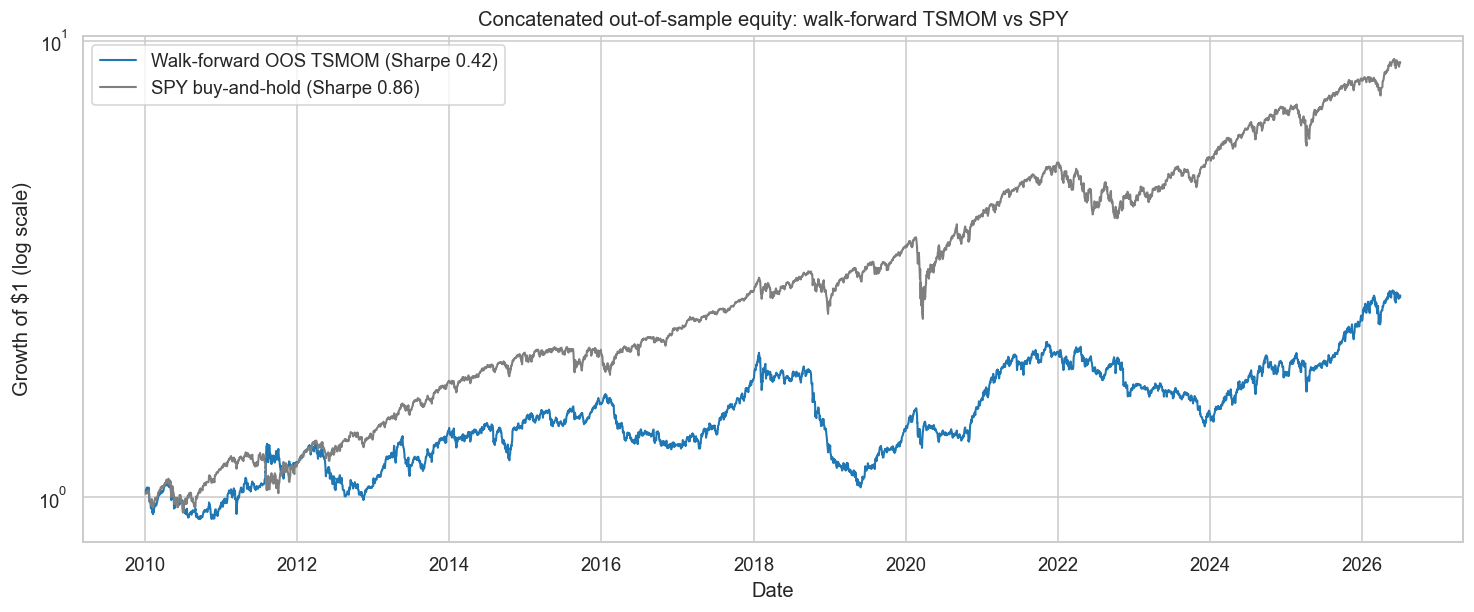

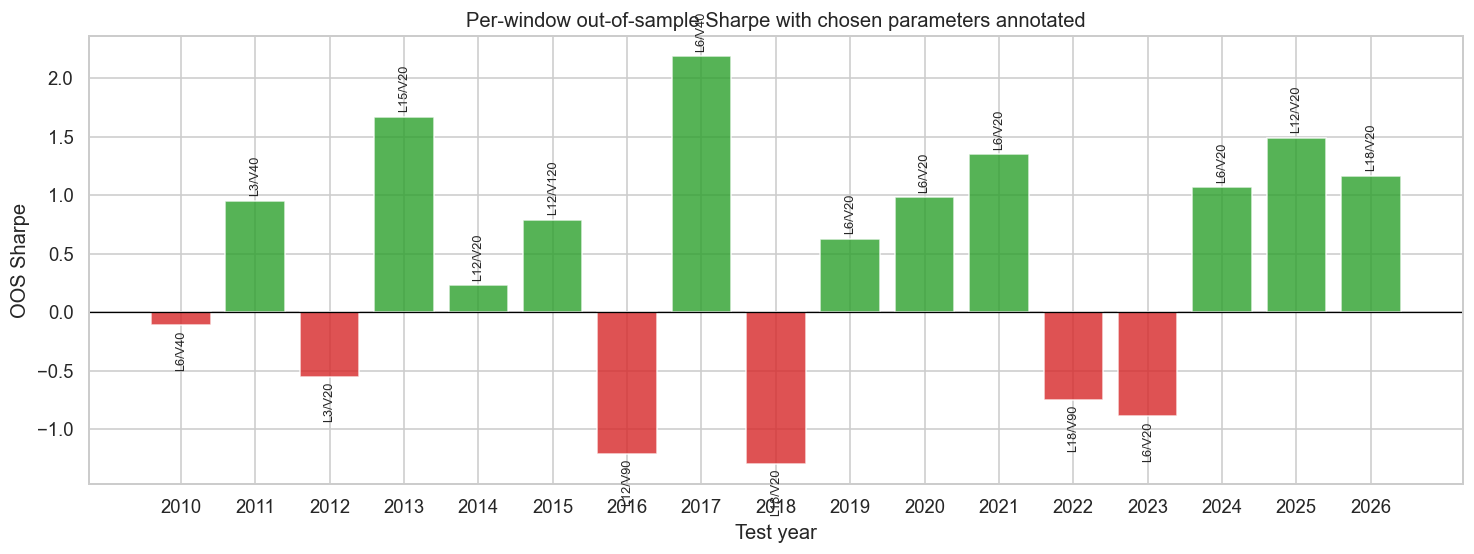

,Train,Test,L (months),Vol window (days),Train Sharpe,OOS Sharpe
0,2007-2009,2010,6,40,1.02,-0.11
1,2008-2010,2011,3,40,0.71,0.95
2,2009-2011,2012,3,20,0.81,-0.55
3,2010-2012,2013,15,20,0.84,1.67
4,2011-2013,2014,12,20,1.03,0.23
5,2012-2014,2015,12,120,1.15,0.79
6,2013-2015,2016,12,90,1.15,-1.21
7,2014-2016,2017,6,40,0.69,2.19
8,2015-2017,2018,18,20,1.25,-1.29
9,2016-2018,2019,6,20,0.65,0.63


Concatenated walk-forward OOS Sharpe: 0.422


In [4]:
L_GRID = [3, 6, 9, 12, 15, 18]
VW_GRID = [20, 40, 60, 90, 120, 180]

vols = {vw: ewma_vol(vw) for vw in VW_GRID}
grid = {}
for L in L_GRID:
    for vw in VW_GRID:
        grid[(L, vw)] = run_tsmom(L, vw, vol=vols[vw])
print(f'Grid computed: {len(grid)} parameter sets, '
      f'{len(grid[(12, 60)]["ls"]):,} daily observations each')

def sharpe_of(r):
    r = r.dropna()
    if len(r) < 40 or r.std() == 0:
        return np.nan
    return r.mean() / r.std() * np.sqrt(ANN)

last_date = base['ls'].index[-1]
wf_rows, oos_parts = [], []
test_year = 2010
while pd.Timestamp(f'{test_year}-01-01') <= last_date:
    tr0, tr1 = pd.Timestamp(f'{test_year - 3}-01-01'), pd.Timestamp(f'{test_year - 1}-12-31')
    te0, te1 = pd.Timestamp(f'{test_year}-01-01'), pd.Timestamp(f'{test_year}-12-31')
    best_key, best_s = None, -np.inf
    for key, res in grid.items():
        s = sharpe_of(res['ls'].loc[tr0:tr1])
        if s > best_s:
            best_key, best_s = key, s
    oos = grid[best_key]['ls'].loc[te0:te1]
    if len(oos) < 60:
        break
    oos_parts.append(oos)
    wf_rows.append({'Train': f'{tr0.year}-{tr1.year}', 'Test': str(test_year),
                    'L (months)': best_key[0], 'Vol window (days)': best_key[1],
                    'Train Sharpe': best_s, 'OOS Sharpe': sharpe_of(oos)})
    test_year += 1

wf = pd.DataFrame(wf_rows)
oos_all = pd.concat(oos_parts)
oos_sharpe = sharpe_of(oos_all)
spy_wf = spy_ret.loc[oos_all.index[0]:oos_all.index[-1]]

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot((1 + oos_all).cumprod(), label=f'Walk-forward OOS TSMOM (Sharpe {oos_sharpe:.2f})',
        color='tab:blue', lw=1.3)
ax.plot((1 + spy_wf).cumprod(), label=f'SPY buy-and-hold (Sharpe {sharpe_of(spy_wf):.2f})',
        color='tab:gray', lw=1.3)
ax.set_yscale('log')
ax.set_title('Concatenated out-of-sample equity: walk-forward TSMOM vs SPY')
ax.set_xlabel('Date')
ax.set_ylabel('Growth of $1 (log scale)')
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(wf['Test'], wf['OOS Sharpe'],
              color=np.where(wf['OOS Sharpe'] >= 0, 'tab:green', 'tab:red'), alpha=0.8)
for rect, (_, row) in zip(bars, wf.iterrows()):
    ax.annotate(f"L{row['L (months)']}/V{row['Vol window (days)']}",
                (rect.get_x() + rect.get_width() / 2, rect.get_height()),
                ha='center', va='bottom' if rect.get_height() >= 0 else 'top',
                fontsize=8, rotation=90,
                xytext=(0, 3 if rect.get_height() >= 0 else -3), textcoords='offset points')
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Per-window out-of-sample Sharpe with chosen parameters annotated')
ax.set_xlabel('Test year')
ax.set_ylabel('OOS Sharpe')
plt.tight_layout()
plt.show()

display(wf.style
        .format({'Train Sharpe': '{:.2f}', 'OOS Sharpe': '{:.2f}'})
        .background_gradient(subset=['OOS Sharpe'], cmap='RdYlGn', vmin=-1.5, vmax=1.5))
print(f'Concatenated walk-forward OOS Sharpe: {oos_sharpe:.3f}')

Interpretation: the concatenated out-of-sample Sharpe is 0.42, positive in 11 of the 17 test years, so the effect survives honest real-time parameter selection, just at a lower level than the full-sample number. Two cautions stand out. First, the chosen parameters wander all over the grid (short lookbacks with a 20-day vol window win training frequently), which says the training Sharpe ranking is noisy rather than that one setting is truly best. Second, high train Sharpe did not protect the bad years: 2016, 2018, and 2022-2023 were walk-forward losers despite confident in-sample picks. The takeaway is to treat parameter choice as roughly interchangeable within the plateau (next section) instead of optimizing it.

## Parameter Stability

A robust strategy should perform similarly across neighboring parameter choices: a broad plateau of good Sharpe ratios suggests a real effect, while a single spike surrounded by weak cells is the classic signature of overfitting. We run the full-sample long-short backtest for every combination of L in {3, 6, 9, 12, 15, 18} months and vol window in {20, 40, 60, 90, 120, 180} days, and map both Sharpe and max drawdown.

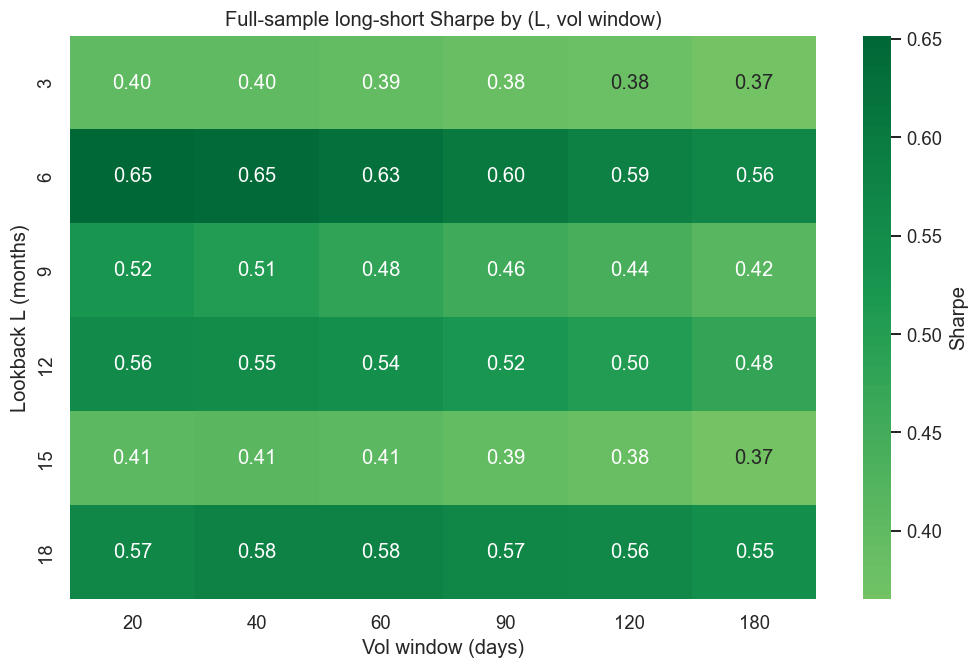

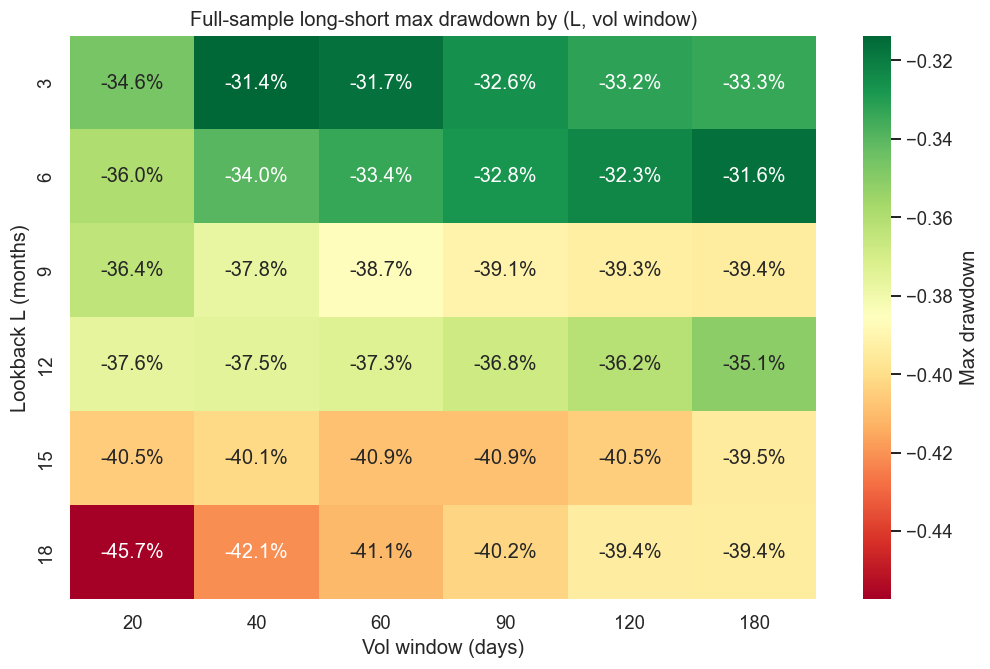

Sharpe range across grid: 0.37 to 0.65
Chosen cell (L=12, vw=60) Sharpe: 0.54


In [5]:
sharpe_grid = pd.DataFrame(index=L_GRID, columns=VW_GRID, dtype=float)
mdd_grid = pd.DataFrame(index=L_GRID, columns=VW_GRID, dtype=float)
for (L, vw), res in grid.items():
    sharpe_grid.loc[L, vw] = sharpe_of(res['ls'])
    mdd_grid.loc[L, vw] = drawdown_series(res['ls']).min()

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(sharpe_grid.astype(float), annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, cbar_kws={'label': 'Sharpe'})
ax.set_title('Full-sample long-short Sharpe by (L, vol window)')
ax.set_xlabel('Vol window (days)')
ax.set_ylabel('Lookback L (months)')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(mdd_grid.astype(float), annot=True, fmt='.1%', cmap='RdYlGn',
            ax=ax, cbar_kws={'label': 'Max drawdown'})
ax.set_title('Full-sample long-short max drawdown by (L, vol window)')
ax.set_xlabel('Vol window (days)')
ax.set_ylabel('Lookback L (months)')
plt.tight_layout()
plt.show()

print(f'Sharpe range across grid: {sharpe_grid.min().min():.2f} to {sharpe_grid.max().max():.2f}')
print(f'Chosen cell (L=12, vw=60) Sharpe: {sharpe_grid.loc[12, 60]:.2f}')

Interpretation: this is a plateau, not a spike. Every one of the 36 cells has a positive full-sample Sharpe, ranging from 0.37 to 0.65, and the surface is nearly flat along the vol-window axis (rows barely change from 20 to 180 days), so vol estimation detail is a second-order choice. The lookback matters more: L = 6 and the long lookbacks (12-18 months) are the strong rows, while L = 3 is the weakest, consistent with the literature that very short trend signals mostly trade noise. The chosen cell (L=12, vw=60) sits comfortably in the middle of the plateau rather than on a lucky peak, which is what we want for live deployment.

## Monte Carlo Robustness

We stress each parameter set with a block bootstrap of its daily net returns: 21-day blocks with uniformly random start points are tiled (circularly) to the original sample length, which preserves short-horizon autocorrelation and volatility clustering, approximating the stationary bootstrap of Politis and Romano. Each of the 36 grid combos gets 300 resamples, implemented fully vectorized in numpy. Three views: the bootstrapped Sharpe distribution for the chosen parameters (L=12, vol window=60), a worst-case (5th percentile) Sharpe heatmap across the whole grid, and a fan chart of resampled equity paths.

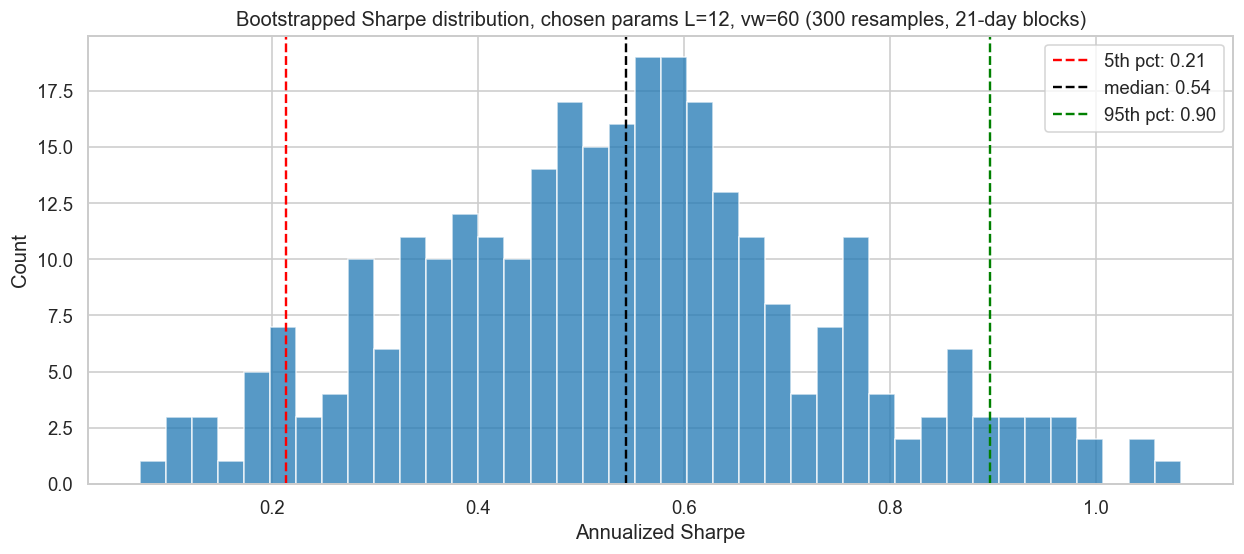

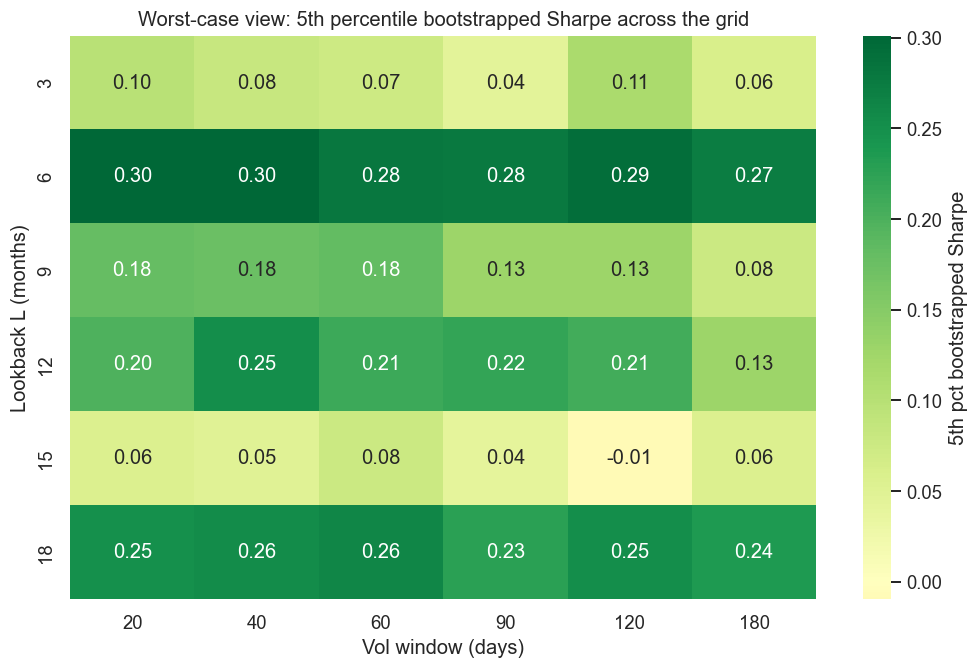

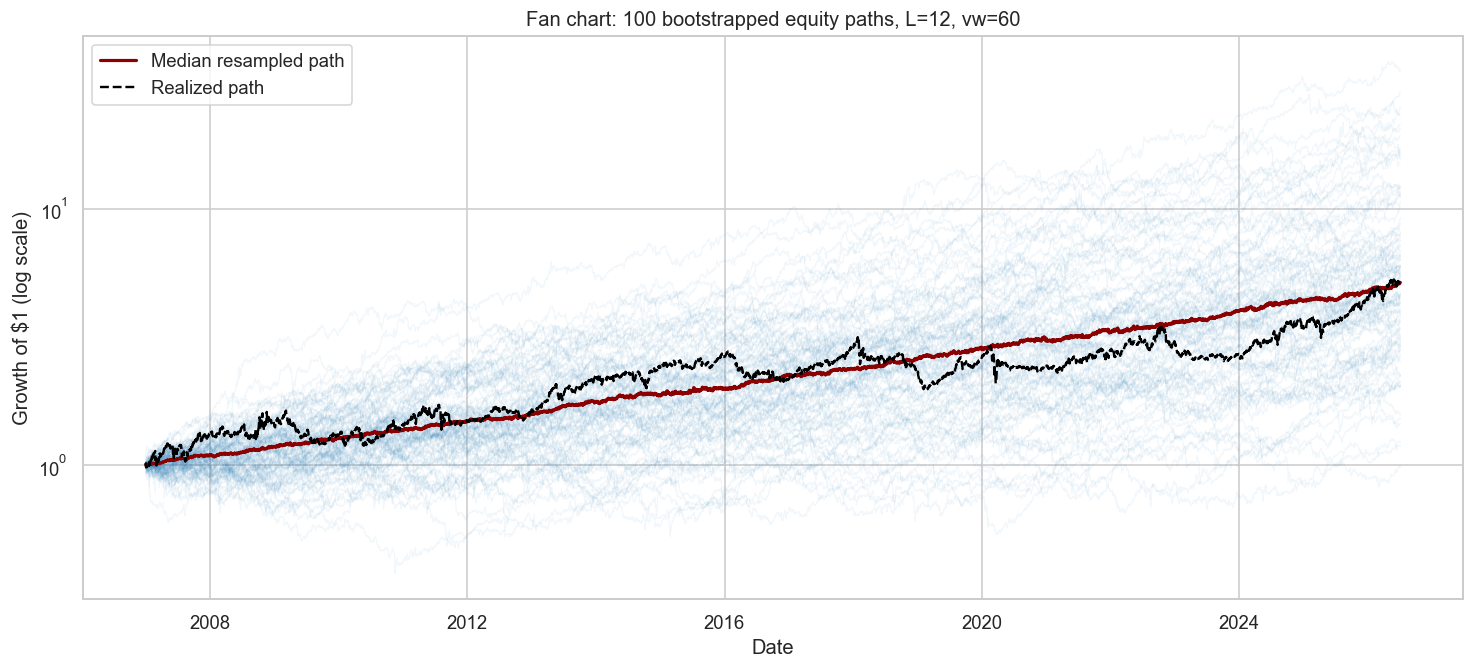

,Sharpe,Max drawdown
5th pct,0.21,-59.92%
25th pct,0.40,-46.39%
50th pct,0.54,-39.34%
75th pct,0.65,-33.55%
95th pct,0.90,-27.83%


MC 5th pct Sharpe (chosen params): 0.213


In [6]:
N_BOOT = 300
BLOCK = 21
CHOSEN = (12, 60)

def block_bootstrap(x, n_boot, block, rng):
    """Circular block bootstrap: (n_boot, len(x)) resampled daily return matrix."""
    n = len(x)
    nb = int(np.ceil(n / block))
    starts = rng.integers(0, n, size=(n_boot, nb))
    idx = (starts[:, :, None] + np.arange(block)[None, None, :]) % n
    return x[idx.reshape(n_boot, -1)[:, :n]]

rng = np.random.default_rng(7)
boot_sharpes = {}
chosen_samp = None
for (L, vw), res in sorted(grid.items()):
    x = res['ls'].dropna().values
    samp = block_bootstrap(x, N_BOOT, BLOCK, rng)
    sd = samp.std(axis=1)
    boot_sharpes[(L, vw)] = np.where(sd > 0, samp.mean(axis=1) / sd * np.sqrt(ANN), np.nan)
    if (L, vw) == CHOSEN:
        chosen_samp = samp

sh_ch = boot_sharpes[CHOSEN]
p5, p50, p95 = np.percentile(sh_ch, [5, 50, 95])

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(sh_ch, bins=40, color='tab:blue', alpha=0.75, edgecolor='white')
for val, lab, c in [(p5, '5th pct', 'red'), (p50, 'median', 'black'), (p95, '95th pct', 'green')]:
    ax.axvline(val, color=c, ls='--', lw=1.5, label=f'{lab}: {val:.2f}')
ax.set_title(f'Bootstrapped Sharpe distribution, chosen params L={CHOSEN[0]}, vw={CHOSEN[1]} '
             f'({N_BOOT} resamples, {BLOCK}-day blocks)')
ax.set_xlabel('Annualized Sharpe')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

p5_grid = pd.DataFrame(index=L_GRID, columns=VW_GRID, dtype=float)
for (L, vw), sh in boot_sharpes.items():
    p5_grid.loc[L, vw] = np.percentile(sh, 5)
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(p5_grid.astype(float), annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, cbar_kws={'label': '5th pct bootstrapped Sharpe'})
ax.set_title('Worst-case view: 5th percentile bootstrapped Sharpe across the grid')
ax.set_xlabel('Vol window (days)')
ax.set_ylabel('Lookback L (months)')
plt.tight_layout()
plt.show()

eq_paths = np.cumprod(1.0 + chosen_samp, axis=1)
dates = grid[CHOSEN]['ls'].dropna().index
fig, ax = plt.subplots(figsize=(13, 6))
for k in range(100):
    ax.plot(dates, eq_paths[k], color='tab:blue', alpha=0.06, lw=0.7)
median_path = np.median(eq_paths, axis=0)
ax.plot(dates, median_path, color='darkred', lw=2.0, label='Median resampled path')
ax.plot(dates, (1.0 + grid[CHOSEN]['ls'].dropna()).cumprod().values,
        color='black', lw=1.5, ls='--', label='Realized path')
ax.set_yscale('log')
ax.set_title(f'Fan chart: 100 bootstrapped equity paths, L={CHOSEN[0]}, vw={CHOSEN[1]}')
ax.set_xlabel('Date')
ax.set_ylabel('Growth of $1 (log scale)')
ax.legend()
plt.tight_layout()
plt.show()

peaks = np.maximum.accumulate(eq_paths, axis=1)
mdds = (eq_paths / peaks - 1.0).min(axis=1)
pcts = [5, 25, 50, 75, 95]
mc_tbl = pd.DataFrame({
    'Sharpe': np.percentile(sh_ch, pcts),
    'Max drawdown': np.percentile(mdds, pcts),
}, index=[f'{p}th pct' for p in pcts])
display(mc_tbl.style
        .format({'Sharpe': '{:.2f}', 'Max drawdown': '{:.2%}'})
        .background_gradient(subset=['Sharpe'], cmap='RdYlGn'))
print(f'MC 5th pct Sharpe (chosen params): {p5:.3f}')

Interpretation: for the chosen parameters the bootstrapped Sharpe distribution is centered at 0.54 with a 5th percentile of 0.21 and a 95th of 0.90, so an unlucky-but-plausible reshuffling of history still leaves the strategy modestly positive. The worst-case heatmap tells the same story grid-wide: the 5th percentile Sharpe is non-negative for 35 of 36 cells (only L=15 with the 120-day window dips a hair below zero), meaning robustness is a property of the strategy, not of one parameter pick. The sobering number is the drawdown table: a 5th percentile max drawdown near -60% says a 40 percent vol target on a 0.5-Sharpe strategy can produce brutal paths, an argument for running it at a fraction of the paper's leverage in a small account.

## Cluster Analysis

Two complementary clustering exercises. First, **parameter clustering**: we correlate the daily return streams of all 36 parameter sets and hierarchically cluster them (average linkage on a 1 minus correlation distance). If the chosen parameters sit inside a large, tight cluster, the exact choice barely matters (robust); if they sit in a small isolated cluster, that is an overfitting warning.

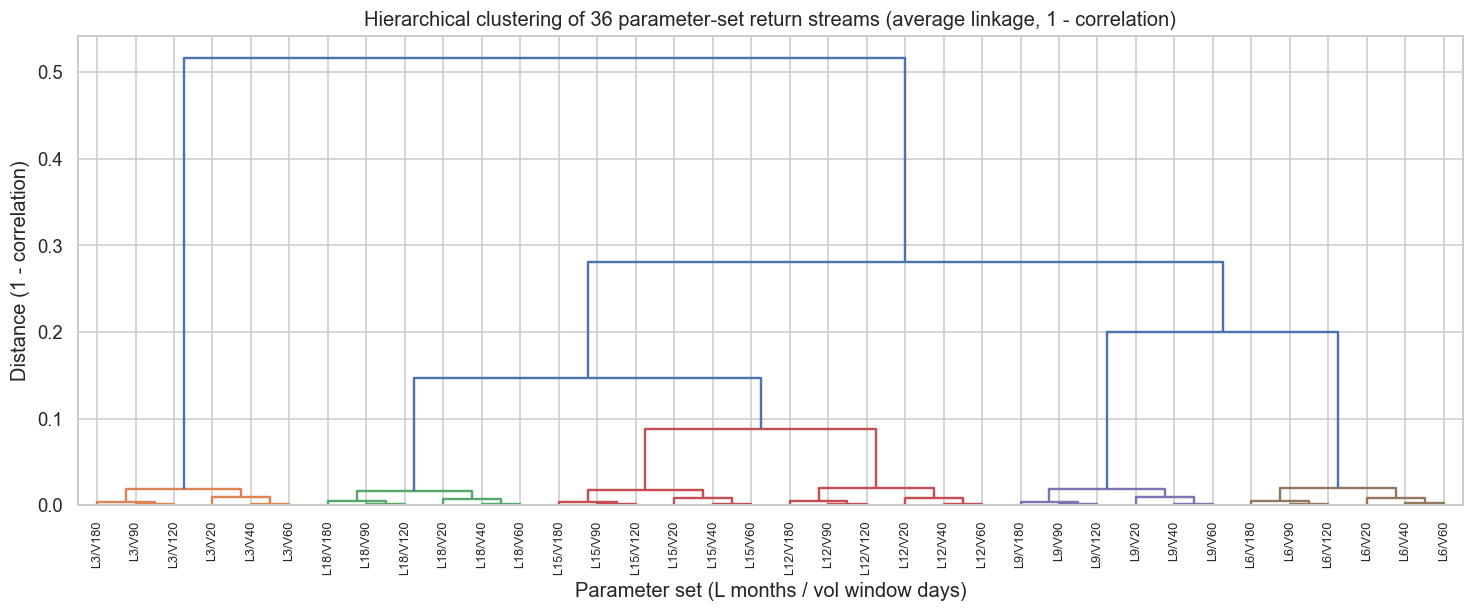

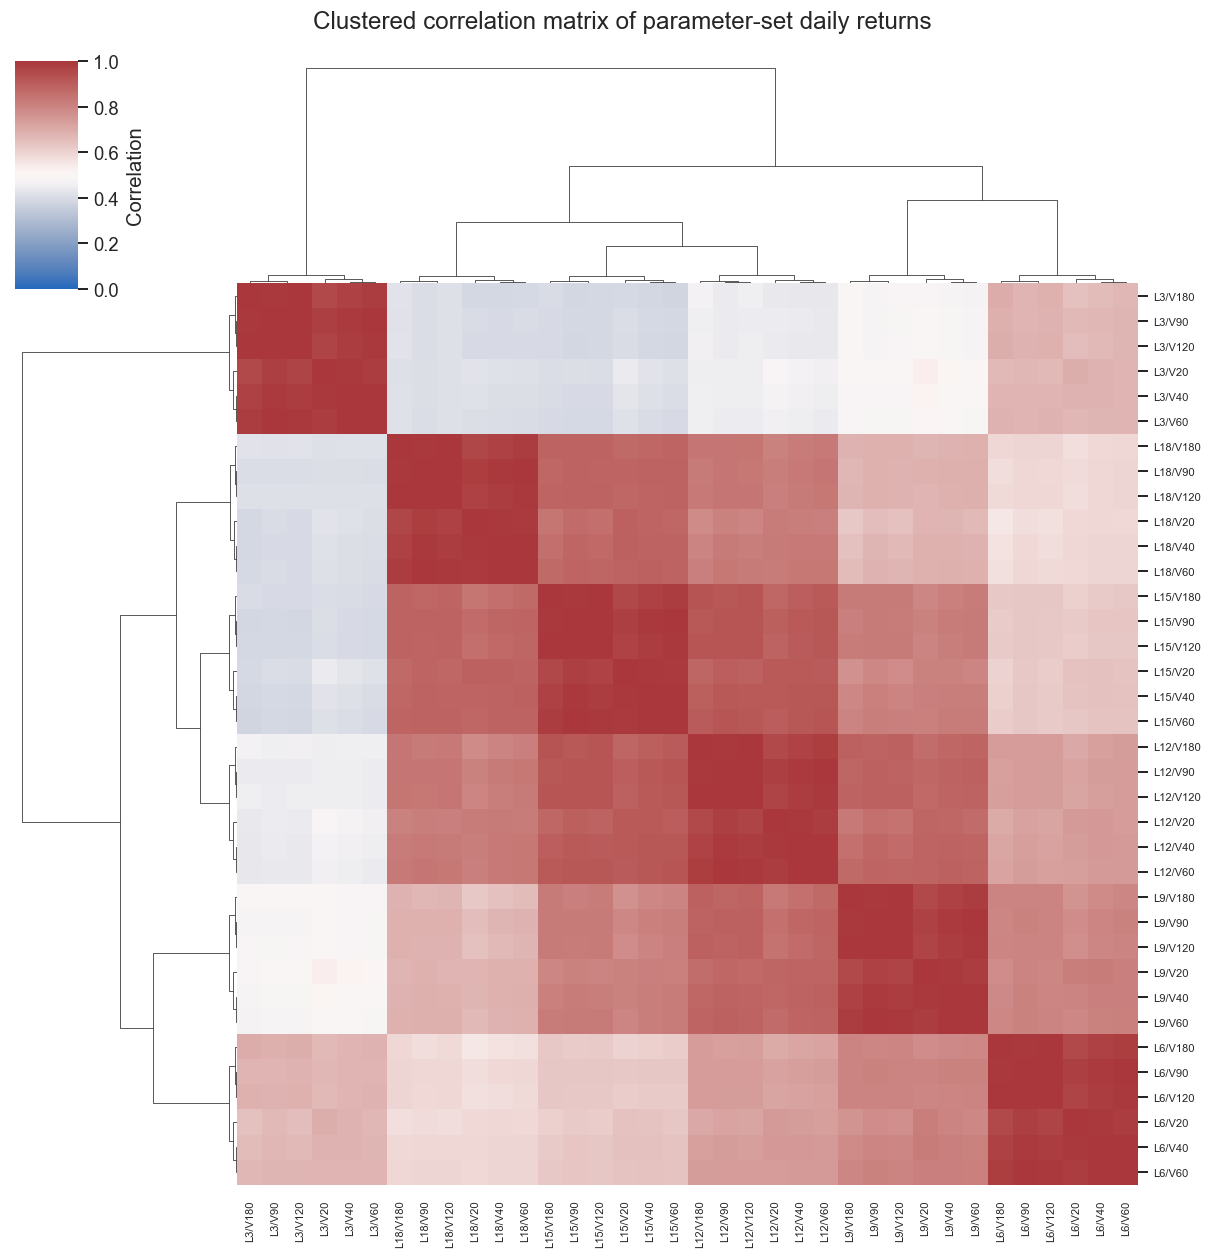

Cluster sizes (4 clusters): {1: 6, 2: 18, 3: 6, 4: 6}
Chosen params L12/V60 sit in cluster 2 with 18 members:
['L12/V20', 'L12/V40', 'L12/V60', 'L12/V90', 'L12/V120', 'L12/V180', 'L15/V20', 'L15/V40', 'L15/V60', 'L15/V90', 'L15/V120', 'L15/V180', 'L18/V20', 'L18/V40', 'L18/V60', 'L18/V90', 'L18/V120', 'L18/V180']
Mean pairwise correlation within chosen cluster: 0.906


In [7]:
labels = [f'L{L}/V{vw}' for L in L_GRID for vw in VW_GRID]
R = pd.DataFrame({f'L{L}/V{vw}': grid[(L, vw)]['ls'] for L in L_GRID for vw in VW_GRID})
C = R.corr()

D = 1.0 - C.values
np.fill_diagonal(D, 0.0)
D = np.clip((D + D.T) / 2.0, 0.0, None)
Z = linkage(squareform(D, checks=False), method='average')

fig, ax = plt.subplots(figsize=(13, 5.5))
dendrogram(Z, labels=C.columns.tolist(), ax=ax, leaf_rotation=90, leaf_font_size=8,
           color_threshold=0.10)
ax.set_title('Hierarchical clustering of 36 parameter-set return streams (average linkage, 1 - correlation)')
ax.set_xlabel('Parameter set (L months / vol window days)')
ax.set_ylabel('Distance (1 - correlation)')
plt.tight_layout()
plt.show()

g = sns.clustermap(C, row_linkage=Z, col_linkage=Z, cmap='vlag', vmin=0.0, vmax=1.0,
                   figsize=(11, 11), xticklabels=1, yticklabels=1,
                   cbar_kws={'label': 'Correlation'})
g.ax_heatmap.tick_params(labelsize=7)
g.fig.suptitle('Clustered correlation matrix of parameter-set daily returns', y=1.02)
plt.show()

cl = fcluster(Z, t=4, criterion='maxclust')
membership = pd.Series(cl, index=C.columns)
chosen_label = f'L{CHOSEN[0]}/V{CHOSEN[1]}'
chosen_cluster = membership[chosen_label]
members = membership[membership == chosen_cluster].index.tolist()
print(f'Cluster sizes (4 clusters): {membership.value_counts().sort_index().to_dict()}')
print(f'Chosen params {chosen_label} sit in cluster {chosen_cluster} '
      f'with {len(members)} members:')
print(members)
print(f'Mean pairwise correlation within chosen cluster: '
      f'{C.loc[members, members].values[np.triu_indices(len(members), 1)].mean():.3f}')

Interpretation: the chosen parameters (L12/V60) belong to the largest cluster, 18 of the 36 sets, containing every combination with L in {12, 15, 18} across all vol windows, with a mean pairwise correlation of 0.91. That is the robust outcome: the long-lookback family is one big, nearly interchangeable strategy, and our pick is a representative member rather than an isolated outlier (which would have been an overfitting red flag). The dendrogram also shows the shorter lookbacks (L=3 and L=6) forming their own distinct families, confirming that the lookback horizon, not the vol window, is the economically meaningful dimension of this grid.

Second, **regime clustering**: we cluster the market environment itself with KMeans (k = 3) on two SPY features, rolling 63-day realized volatility and rolling 126-day return, then measure how the strategy performs in each regime. Trend following should shine in sustained bull or bear regimes and struggle in choppy transitions.

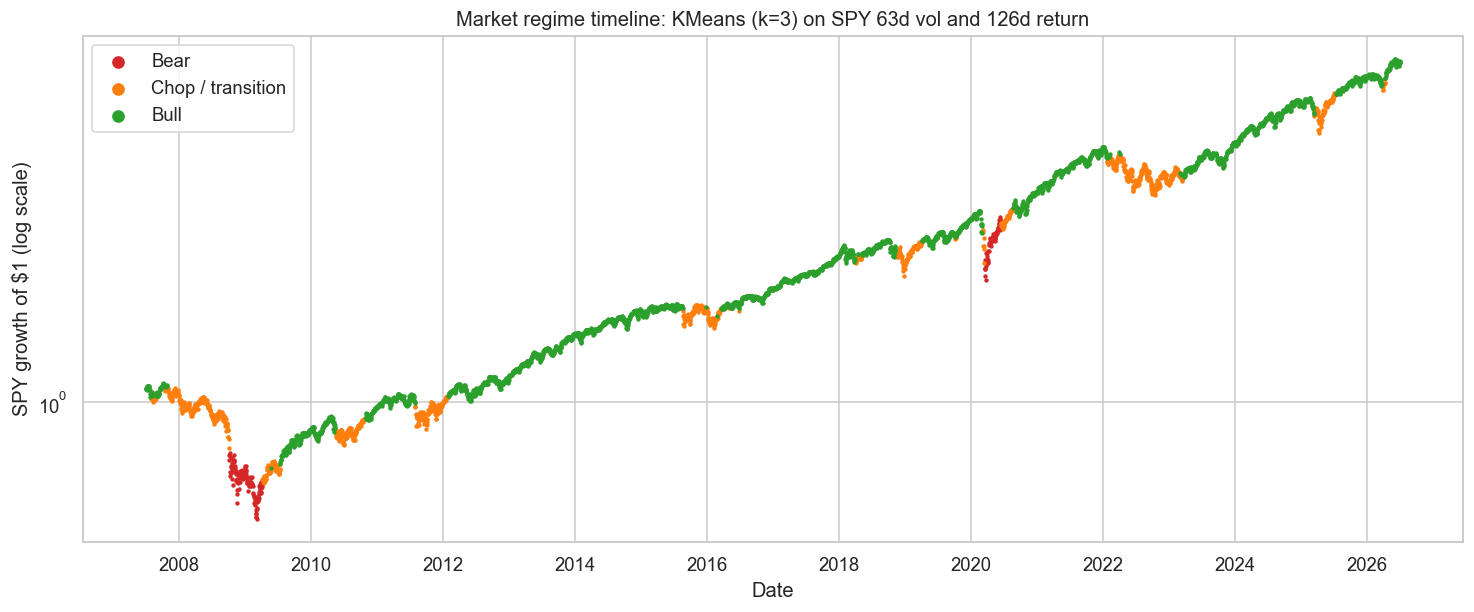

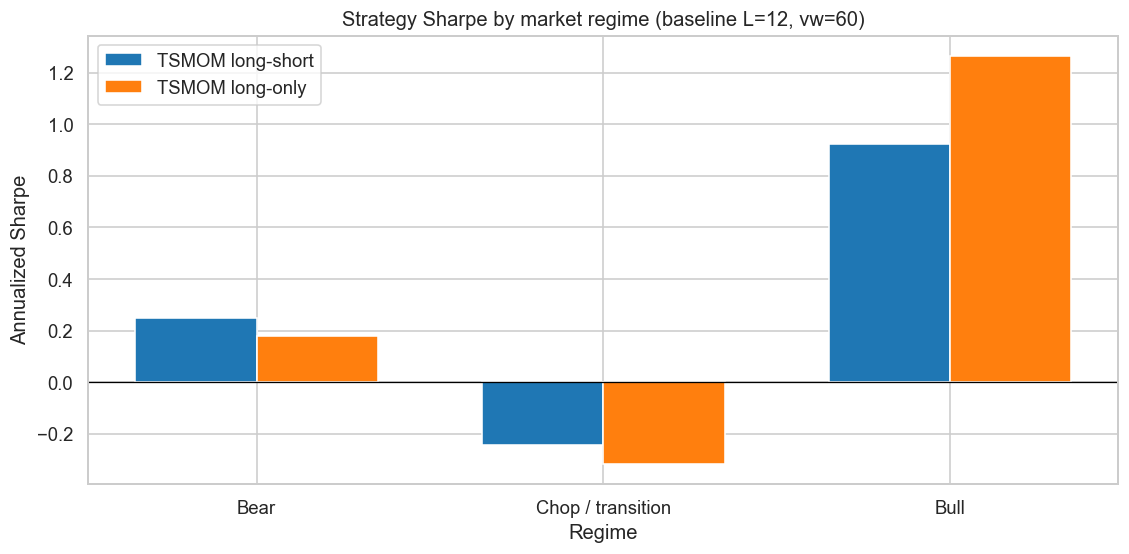

,Days,Long-short Sharpe,Long-only Sharpe,SPY Sharpe
Regime,,,,
Bear,191,0.25,0.18,0.06
Chop / transition,"1,271",-0.24,-0.32,-0.23
Bull,"3,318",0.92,1.26,1.52


In [8]:
spy_r = rets_full['SPY'].loc[START:].fillna(0.0)
vol63 = spy_r.rolling(63).std() * np.sqrt(ANN)
ret126 = np.exp(np.log1p(spy_r).rolling(126).sum()) - 1.0
feat = pd.DataFrame({'vol63': vol63, 'ret126': ret126}).dropna()

X = StandardScaler().fit_transform(feat.values)
km = KMeans(n_clusters=3, n_init=10, random_state=42).fit(X)
feat['raw_label'] = km.labels_

order = feat.groupby('raw_label')['ret126'].mean().sort_values().index.tolist()
name_map = {order[0]: 'Bear', order[1]: 'Chop / transition', order[2]: 'Bull'}
feat['regime'] = feat['raw_label'].map(name_map)
regime_colors = {'Bear': 'tab:red', 'Chop / transition': 'tab:orange', 'Bull': 'tab:green'}

spy_eq = (1.0 + spy_r).cumprod().loc[feat.index]
fig, ax = plt.subplots(figsize=(13, 5.5))
for reg, c in regime_colors.items():
    mask = feat['regime'] == reg
    ax.scatter(spy_eq.index[mask], spy_eq.values[mask], s=3, color=c, label=reg)
ax.set_yscale('log')
ax.set_title('Market regime timeline: KMeans (k=3) on SPY 63d vol and 126d return')
ax.set_xlabel('Date')
ax.set_ylabel('SPY growth of $1 (log scale)')
ax.legend(markerscale=4)
plt.tight_layout()
plt.show()

regime_rows = []
for reg in ['Bear', 'Chop / transition', 'Bull']:
    idx = feat.index[feat['regime'] == reg]
    regime_rows.append({'Regime': reg, 'Days': len(idx),
                        'Long-short Sharpe': sharpe_of(base['ls'].loc[base['ls'].index.isin(idx)]),
                        'Long-only Sharpe': sharpe_of(base['lo'].loc[base['lo'].index.isin(idx)]),
                        'SPY Sharpe': sharpe_of(spy_r.loc[spy_r.index.isin(idx)])})
regime_tbl = pd.DataFrame(regime_rows).set_index('Regime')

fig, ax = plt.subplots(figsize=(10, 5))
xpos = np.arange(len(regime_tbl))
w = 0.35
ax.bar(xpos - w / 2, regime_tbl['Long-short Sharpe'], w, label='TSMOM long-short',
       color='tab:blue')
ax.bar(xpos + w / 2, regime_tbl['Long-only Sharpe'], w, label='TSMOM long-only',
       color='tab:orange')
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(xpos)
ax.set_xticklabels(regime_tbl.index)
ax.set_title('Strategy Sharpe by market regime (baseline L=12, vw=60)')
ax.set_xlabel('Regime')
ax.set_ylabel('Annualized Sharpe')
ax.legend()
plt.tight_layout()
plt.show()

display(regime_tbl.style
        .format({'Days': '{:,.0f}', 'Long-short Sharpe': '{:.2f}',
                 'Long-only Sharpe': '{:.2f}', 'SPY Sharpe': '{:.2f}'})
        .background_gradient(subset=['Long-short Sharpe', 'Long-only Sharpe'],
                             cmap='RdYlGn', axis=None))

Interpretation: the pattern matches the trend-following playbook. In the bull regime (about 3,300 days) both variants do well (long-short Sharpe 0.92, long-only 1.26). In the chop / transition regime (about 1,270 days) both bleed (-0.24 and -0.32): whipsaw is where TSMOM pays its dues. The KMeans bear regime is tiny here (191 extreme-vol days, mostly late 2008 and March 2020), too small for strong conclusions, but the long-short book at least stays positive (0.25) while SPY is flat, hinting at the crisis-alpha property documented in the papers. Note the long-only variant loses that crisis hedge by construction: in a fast bear it can only stand in cash.

## Decision Summary

We pull the headline evidence into one table: baseline and walk-forward performance, the Monte Carlo worst-case range, and diversification value measured as correlation of the strategy's monthly returns to SPY and to a 12-1 cross-sectional momentum long-only proxy (each month, hold the top 6 ETFs by return from month t-12 to t-1, equal weight).

In [9]:
mom = mclose.shift(1) / mclose.shift(12) - 1.0
ranks = mom.rank(axis=1, ascending=False)
w_xs = (ranks <= 6).astype(float)
w_xs = w_xs.div(w_xs.sum(axis=1).clip(lower=1.0), axis=0)
wd_xs = w_xs.reindex(full_index).ffill().shift(1).fillna(0.0)
xs_ret = (wd_xs * rets_full).sum(axis=1).loc[START:]

def monthly_rets(r):
    return (1.0 + r).resample('ME').prod() - 1.0

m_ls, m_lo = monthly_rets(base['ls']), monthly_rets(base['lo'])
m_spy, m_xs = monthly_rets(spy_ret), monthly_rets(xs_ret)

corr_spy_ls = m_ls.corr(m_spy)
corr_xs_ls = m_ls.corr(m_xs)
corr_spy_lo = m_lo.corr(m_spy)
corr_xs_lo = m_lo.corr(m_xs)

summary = pd.DataFrame({'Value': {
    'Baseline long-short Sharpe (net)': f"{metrics_tbl.loc['TSMOM long-short', 'Sharpe']:.2f}",
    'Baseline long-only Sharpe (net)': f"{metrics_tbl.loc['TSMOM long-only', 'Sharpe']:.2f}",
    'Walk-forward OOS Sharpe': f'{oos_sharpe:.2f}',
    'MC Sharpe range, 5th to 50th pct (chosen params)': f'{p5:.2f} to {p50:.2f}',
    'MC max drawdown, 5th pct worst case': f'{np.percentile(mdds, 5):.1%}',
    'Monthly corr to SPY (long-short / long-only)': f'{corr_spy_ls:.2f} / {corr_spy_lo:.2f}',
    'Monthly corr to 12-1 momentum long-only proxy (LS / LO)': f'{corr_xs_ls:.2f} / {corr_xs_lo:.2f}',
    'Parameter cluster of chosen params': f'{len(members)} of 36 sets, '
                                          f'cluster {chosen_cluster} of 4',
    'Suggested Alpaca deployment': 'Long-only variant, $5k budget, monthly rebalance',
}})
summary.index.name = 'Item'
display(summary.style.set_properties(**{'text-align': 'left'}))

print('HEADLINE SUMMARY')
print(f"baseline_ls_sharpe={metrics_tbl.loc['TSMOM long-short', 'Sharpe']:.3f}")
print(f"baseline_lo_sharpe={metrics_tbl.loc['TSMOM long-only', 'Sharpe']:.3f}")
print(f'wf_oos_sharpe={oos_sharpe:.3f}')
print(f'mc_p5_sharpe={p5:.3f}')
print(f'mc_p50_sharpe={p50:.3f}')
print(f'corr_spy_ls={corr_spy_ls:.3f}')
print(f'corr_xs_ls={corr_xs_ls:.3f}')
print(f'chosen_cluster_size={len(members)}')

,Value
Item,
Baseline long-short Sharpe (net),0.54
Baseline long-only Sharpe (net),0.75
Walk-forward OOS Sharpe,0.42
"MC Sharpe range, 5th to 50th pct (chosen params)",0.21 to 0.54
"MC max drawdown, 5th pct worst case",-59.9%
Monthly corr to SPY (long-short / long-only),0.11 / 0.63
Monthly corr to 12-1 momentum long-only proxy (LS / LO),0.46 / 0.75
Parameter cluster of chosen params,"18 of 36 sets, cluster 2 of 4"
Suggested Alpaca deployment,"Long-only variant, $5k budget, monthly rebalance"


HEADLINE SUMMARY
baseline_ls_sharpe=0.541
baseline_lo_sharpe=0.755
wf_oos_sharpe=0.422
mc_p5_sharpe=0.213
mc_p50_sharpe=0.544
corr_spy_ls=0.111
corr_xs_ls=0.463
chosen_cluster_size=18


**Verdict: deploy the long-only variant, small.** The TSMOM effect is real in this universe: every parameter cell is profitable, the walk-forward OOS Sharpe is 0.42, the chosen parameters sit in the largest and tightest cluster (18 of 36 sets, 0.91 mean correlation), and Monte Carlo puts a realistic live Sharpe in the 0.2 to 0.55 range (5th to 50th percentile). The long-short book is the better diversifier (0.11 monthly correlation to SPY) but is not implementable on the long-only Alpaca paper account, so we deploy the long-only variant, accepting its higher SPY correlation (0.63) and its overlap with the existing Clenow momentum sleeve (0.75 correlation to the 12-1 momentum proxy argues for a modest allocation, not a flagship one).

**Suggested deployment**: long-only TSMOM (L=12 months, 60-day EWMA vol, sigma target scaled down to roughly 15-20% rather than the paper's 40%), $5k budget, rebalance on the last trading day of each month, orders placed next open, consistent with this repo's strategy contract.

**Key risks**: (1) whipsaw bleed in chop / transition regimes, where measured Sharpe is negative; (2) short-side economics (ETF borrow, margin) are not modeled, so the headline long-short numbers are optimistic and only the long-only variant should be trusted for live purposes; (3) 10 bps costs may understate slippage in thin ETFs like DBB or UNG; (4) the 2007-2026 sample is dominated by an equity bull market, flattering the long-only variant; (5) a Monte Carlo worst-case drawdown near -60% at full 40% vol targeting demands the reduced sizing suggested above.